In [1]:
from models.rvm_tf import RecurrentWorldModel
import torch
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
with open("/home/rvm/configs/train_ema.yaml", "r") as f:
    config = yaml.safe_load(f)
model = RecurrentWorldModel(**config.get("model", {}))

/root/miniconda3/envs/gssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading the vision encoder from facebook/dinov2-with-registers-small


Loading weights: 100%|██████████| 224/224 [00:00<00:00, 10510.28it/s]

Objective is pixel reconstruction



ic| self.objective: 'pixel'


In [3]:
checkpoint = torch.load("/home/rvm/checkpoints/checkpoints_rwm_recon/exp_1787642375.8306108/model_epoch2_step6000.pth", weights_only=False)
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [4]:
video_path = '/home/rvm/src/c99d46743f5a5760705af190faa69e1bacae4b788c1e44c901c47b78de7ab7cc.mp4'
import cv2
cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Cannot open video")

frames = []
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (252, 252))
    frame = frame/255.0
    frames.append(frame)    

print(len(frames))
stride = 10
frames = frames[int(0.2 * len(frames)):]
frames = frames[::stride]
print(len(frames))


636
51


In [5]:
# device = "cuda"
# model = model.to(device)
# model.eval()

# C = 10                          # how many leading frames to use as context
# # S = len(frames) - C            # how many future frames to roll out
# S = 6
# context = torch.tensor(np.stack(frames[:C]), dtype=torch.float32)   # (C, H, W, 3)
# context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)       # (B=1, C, 3, H, W)

# # your frames are already subsampled by stride=10, so consecutive frames
# # are 1 "unit" apart -- keep context_times/gaps in that same unit
# context_times = torch.arange(C, dtype=torch.float32).unsqueeze(0).to(device)  # (1, C)
# gaps = torch.ones(S, dtype=torch.float32).to(device)                           # (S,)

# with torch.no_grad():
#     out = model.rollout(
#         context=context,
#         gaps=gaps,
#         context_times=context_times,
#     )

# pred = out["pred"]              # (B, S, n_tok, D) — feature-space predictions either way
# recon = out.get("recon")        # (B, S, 3, H, W) — only present if model.objective == "pixel"


In [6]:
indices = np.arange(10)
np.random.shuffle(indices)

context_frames = np.stack(frames[:10])[indices]
indices

array([4, 6, 9, 5, 3, 8, 2, 7, 0, 1])

In [ ]:
device = "cuda"
model = model.to(device)
model.eval()

C = 10                          # how many leading frames to use as context
S = 6                            # how many frames to predict (needs ground truth)
indices = np.arange(C)
# np.random.shuffle(indices)
context_frames = np.stack(frames[:C])[indices]

context = torch.tensor(context_frames, dtype=torch.float32)      # (C, H, W, 3)
context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)          # (B=1, C, 3, H, W)

indices = np.arange(S)
# np.random.shuffle(indices)
target_frames = np.stack(frames[C:C+S])[indices]
targets = torch.tensor(target_frames, dtype=torch.float32)  # (S, H, W, 3)
targets = targets.permute(0, 3, 1, 2).unsqueeze(0).to(device)           # (B=1, S, 3, H, W)

# same 1-unit-per-frame convention; target_times continues context_times' clock
context_times = torch.arange(C, dtype=torch.float32).unsqueeze(0).to(device)         # (1, C)
target_times = torch.arange(C, C + S, dtype=torch.float32).unsqueeze(0).to(device)   # (1, S)

with torch.no_grad():
    out_tf = model.teacher_forcing_rollout(
        context=context,
        targets=targets,
        context_times=context_times,
        target_times=target_times,
    )

recon_tf = out_tf["recon"]      # (B, S, 3, H, W)


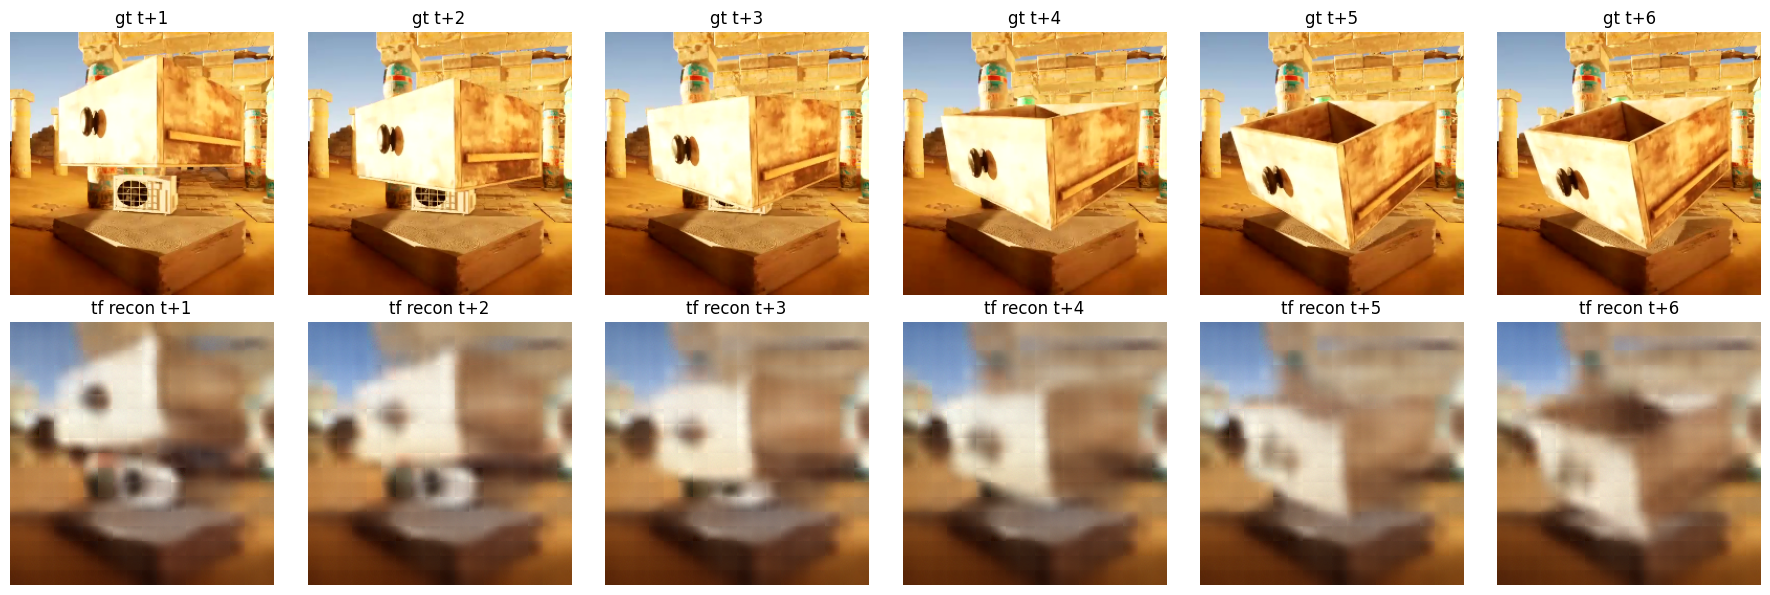

In [8]:
# gt = np.stack(frames[C:C + S])                                  # (S, H, W, 3), in [0,1]
gt = target_frames
recon_np = recon_tf[0].detach().cpu().permute(0, 2, 3, 1).numpy()
recon_np = np.clip(recon_np, 0.0, 1.0)

fig, axes = plt.subplots(2, S, figsize=(3 * S, 6))
for s in range(S):
    axes[0, s].imshow(gt[s])
    axes[0, s].set_title(f"gt t+{s+1}")
    axes[0, s].axis("off")

    axes[1, s].imshow(recon_np[s])
    axes[1, s].set_title(f"tf recon t+{s+1}")
    axes[1, s].axis("off")

plt.tight_layout()
plt.show()


In [9]:
import torch.nn.functional as F

r = recon_tf                                                   # (1, S, 3, H, W)
gt = targets                                                   # (1, S, 3, H, W), shuffled order
prev = torch.cat([context[:, -1:], targets[:, :-1]], dim=1)    # what the core saw one step earlier
mean = gt.mean(dim=1, keepdim=True).expand_as(gt)

def per_step(a, b):                # (S,) MSE, one value per predicted step
    return (a - b).pow(2).flatten(2).mean(-1)[0]

print(f"{'':6} {'all':>8}  " + "  ".join(f"s{i+1:<5}" for i in range(S)))
for name, ref in [("gt", gt), ("prev", prev), ("mean", mean)]:
    ps = per_step(r, ref)
    print(f"{name:6} {F.mse_loss(r, ref).item():8.5f}  " + "  ".join(f"{v:6.5f}" for v in ps))

# does the output move at all as s changes?
print("recon var across s:", r.std(dim=1).mean().item())
print("gt    var across s:", gt.std(dim=1).mean().item())

            all  s1      s2      s3      s4      s5      s6    
gt      0.03629  0.03928  0.03652  0.03180  0.03760  0.04057  0.03195
prev    0.03174  0.03402  0.03058  0.03076  0.03301  0.03035  0.03170
mean    0.03387  0.04430  0.03428  0.03013  0.03199  0.02674  0.03578
recon var across s: 0.06547736376523972
gt    var across s: 0.07016517966985703


In [11]:
out_tf.keys()

dict_keys(['recon', 'target_feat', 'context_memory', 'context_feat', 'state'])

In [15]:
context_feat, context_memory = out_tf['context_feat'].cpu().squeeze(0).numpy(), out_tf['context_memory'].cpu().squeeze(0).numpy()

In [17]:
context_feat.shape

(10, 325, 384)

frame 0: explained variance = [0.254 0.123 0.081]  (sum 0.458)
frame 1: explained variance = [0.225 0.116 0.088]  (sum 0.428)
frame 2: explained variance = [0.221 0.114 0.089]  (sum 0.424)
frame 3: explained variance = [0.22  0.113 0.089]  (sum 0.421)
frame 4: explained variance = [0.22  0.114 0.089]  (sum 0.423)
frame 5: explained variance = [0.218 0.113 0.089]  (sum 0.420)
frame 6: explained variance = [0.219 0.113 0.089]  (sum 0.421)
frame 7: explained variance = [0.22 0.11 0.09]  (sum 0.420)
frame 8: explained variance = [0.218 0.109 0.088]  (sum 0.415)
frame 9: explained variance = [0.216 0.111 0.081]  (sum 0.408)
frame 0: explained variance = [0.185 0.125 0.102]  (sum 0.412)
frame 1: explained variance = [0.187 0.125 0.103]  (sum 0.415)
frame 2: explained variance = [0.187 0.124 0.103]  (sum 0.414)
frame 3: explained variance = [0.187 0.124 0.103]  (sum 0.414)
frame 4: explained variance = [0.184 0.125 0.102]  (sum 0.411)
frame 5: explained variance = [0.183 0.125 0.103]  (sum 0.

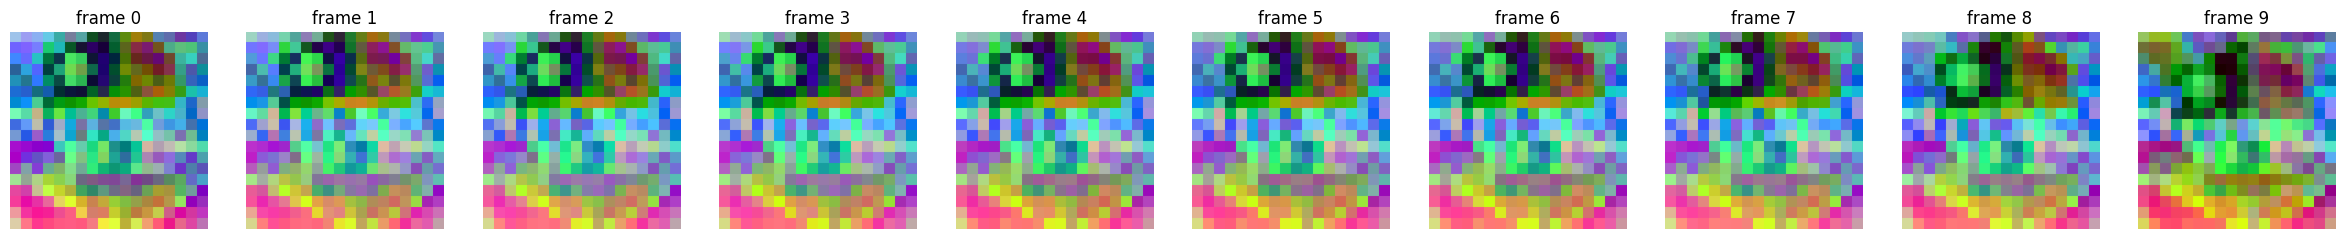

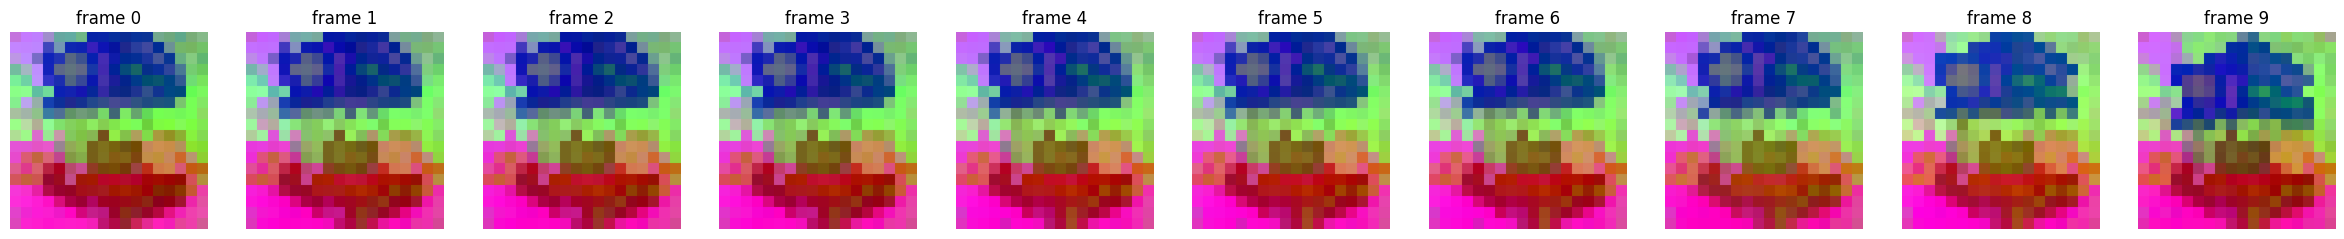

In [20]:
from pca_vis import pca_per_frame, show
mem_pc, con_pc = pca_per_frame(context_memory[:C, 1:, :]), pca_per_frame(context_feat[:, 1:, :])
mem_pc_img, con_pc_img = show(mem_pc), show(con_pc)

In [22]:
context_feat.shape, context_memory.shape

((10, 325, 384), (16, 325, 384))

In [23]:
feats = out_tf["context_feat"]        # (B, C, n_tok, D)
mem   = out_tf["context_memory"]      # (B, C+S, n_tok, D) -- context steps first
C     = feats.shape[1]
m     = mem[:, :C]                    # align to the context frames only

same = torch.cosine_similarity(m, feats, dim=-1).mean(dim=(0, 2))          # (C,)
prev = torch.cosine_similarity(m[:, 1:], feats[:, :-1], dim=-1).mean(dim=(0, 2))  # (C-1,)

print("t   cos(mem_t, feat_t)   cos(mem_t, feat_{t-1})")
for t in range(C):
    p = f"{prev[t-1]:.3f}" if t > 0 else "  -  "
    print(f"{t:<3} {same[t]:>12.3f} {p:>18}")

print(f"\nmean same={same.mean():.3f}  prev={prev.mean():.3f}")

t   cos(mem_t, feat_t)   cos(mem_t, feat_{t-1})
0          0.552                -  
1          0.594              0.593
2          0.596              0.596
3          0.603              0.603
4          0.601              0.598
5          0.602              0.601
6          0.603              0.603
7          0.602              0.594
8          0.597              0.577
9          0.595              0.552

mean same=0.594  prev=0.591
